In [1]:
import numpy as np
import pandas as pd

In [5]:
train = pd.read_csv('/kaggle/input/datasets/ivanpronin/dls-2026-sea/Море качается раз море качается два/train.csv')
test = pd.read_csv('/kaggle/input/datasets/ivanpronin/dls-2026-sea/Море качается раз море качается два/test_waves.csv', delimiter=';')


In [13]:
train.head()

,lambda,h,a,U,c_noisy
0,120.665949,77.186245,7.056568,-0.489613,13.637436
1,166.656769,59.257578,7.954285,1.088948,17.159384
2,172.335206,41.768393,7.342887,-0.219695,15.665923
3,105.871455,56.743689,4.576115,-0.094789,12.607888
4,163.057610,59.771840,4.460710,1.951497,18.298626


In [9]:
test.head()

,lambda,h,a,U
0,87.035667,95.082834,1.338741,0.521352
1,110.723943,27.821534,2.228645,-0.768649
2,26.051663,33.345864,6.539315,-1.134343
3,42.880952,15.116142,1.871697,1.320392
4,4.241804,30.425079,3.852757,1.958453


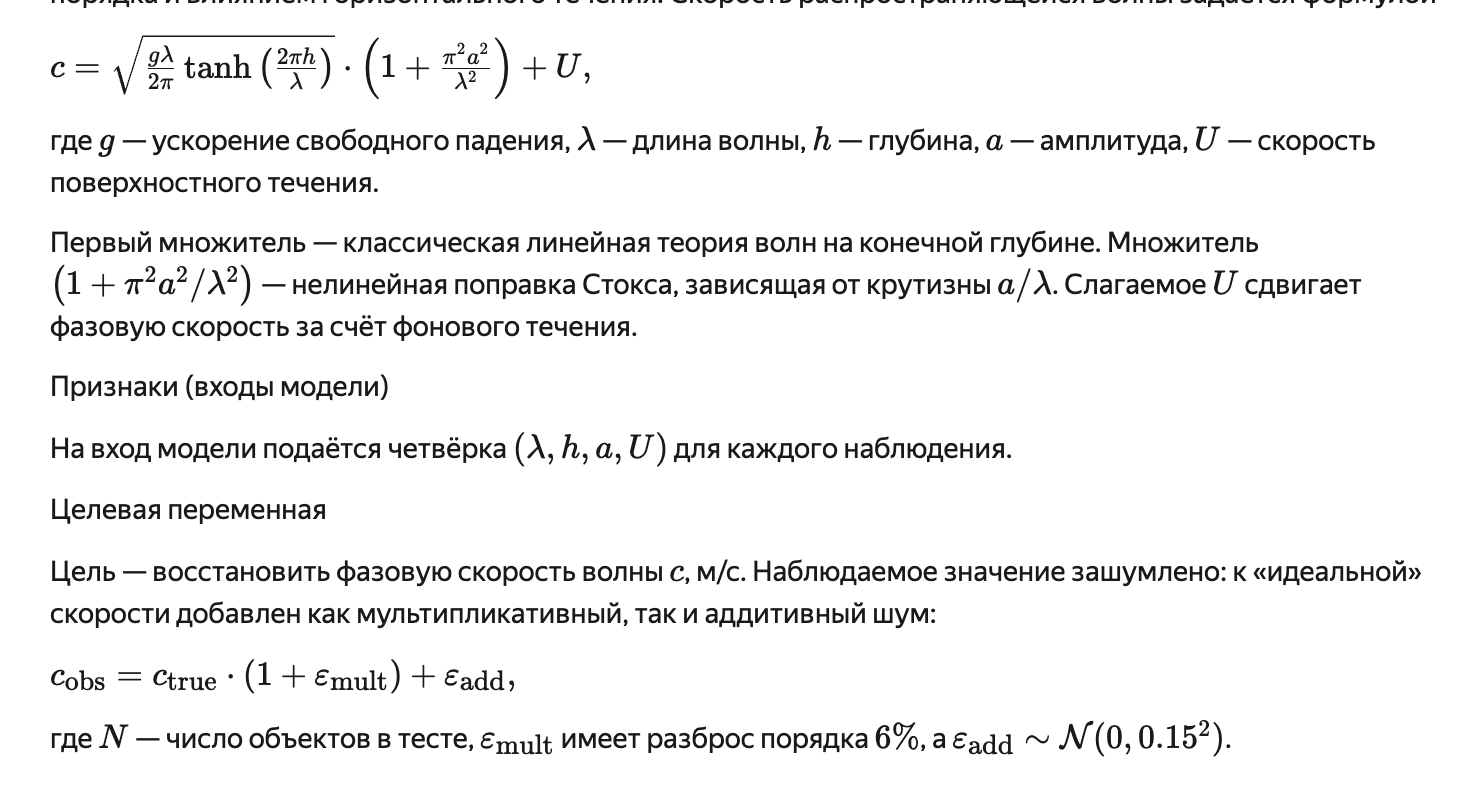

In [27]:
def calculate(row, g):
    lam = row['lambda']
    h = row['h']
    a = row['a']
    u = row['U']

    lin = np.sqrt((g * lam) / (2 * np.pi) * np.tanh(2*np.pi*h/lam))

    cor = lin*(1 + np.pi**2 * a**2 / lam**2) + u

    return cor



In [28]:
from scipy.optimize import minimize, minimize_scalar

In [29]:
def ob(g):
    preds = train.apply(lambda r: calculate(r, g), axis=1)
    return np.sqrt(((preds - train['c_noisy'])).mean())

res = minimize_scalar(ob, bounds=(9,10))

/tmp/ipykernel_55/2366176902.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(((preds - train['c_noisy'])).mean())


In [95]:
best_g = res.x
best_g = 9.806

In [113]:
test_preds = test.apply(lambda r: calculate(r, best_g), axis=1)
test_preds

0        12.203349
1        11.879533
2         9.207247
3         9.556142
4        25.480876
           ...    
11245    12.388347
11246    11.411535
11247    16.271562
11248    12.804102
11249     4.413274
Length: 11250, dtype: float64

In [114]:
test_preds.min()

-0.5063019480440902

In [115]:
sub = pd.DataFrame(test_preds, columns=['c'])

In [116]:
sub.head()

,c
0,12.203349
1,11.879533
2,9.207247
3,9.556142
4,25.480876


In [117]:
sub.to_csv('task_I_sub.csv', index=False)